In [1]:
# 🥊 The OCR Gauntlet: 5 Tiers of OCR Compared
# Companion to "The Definitive Guide to OCR in 2025-2026"

import warnings

warnings.filterwarnings("ignore")

from ocr_gauntlet.engines import check_available_engines
from ocr_gauntlet.utils import (
    load_sample,
    list_samples,
    list_all_samples,
    normalize_text,
    ensure_samples,
)
from ocr_gauntlet.metrics import cer, wer, anls
from ocr_gauntlet.visualize import (
    results_heatmap,
    quality_cliff_chart,
    speed_vs_quality,
    cost_table,
)

# Download samples from HuggingFace if not already present
ensure_samples()

# Check what engines can run
engines = check_available_engines()
print("\nAvailable engines:")
for name, ok in engines.items():
    print(f"  {name}: {'✅' if ok else '❌ (skipped)'}")


Available engines:
  tesseract: ✅
  docling: ✅
  dots_ocr: ❌ (skipped)
  mistral_ocr: ✅
  gemini: ✅


Samples with ground truth (for metrics): 5
All samples (including visual-only):     5



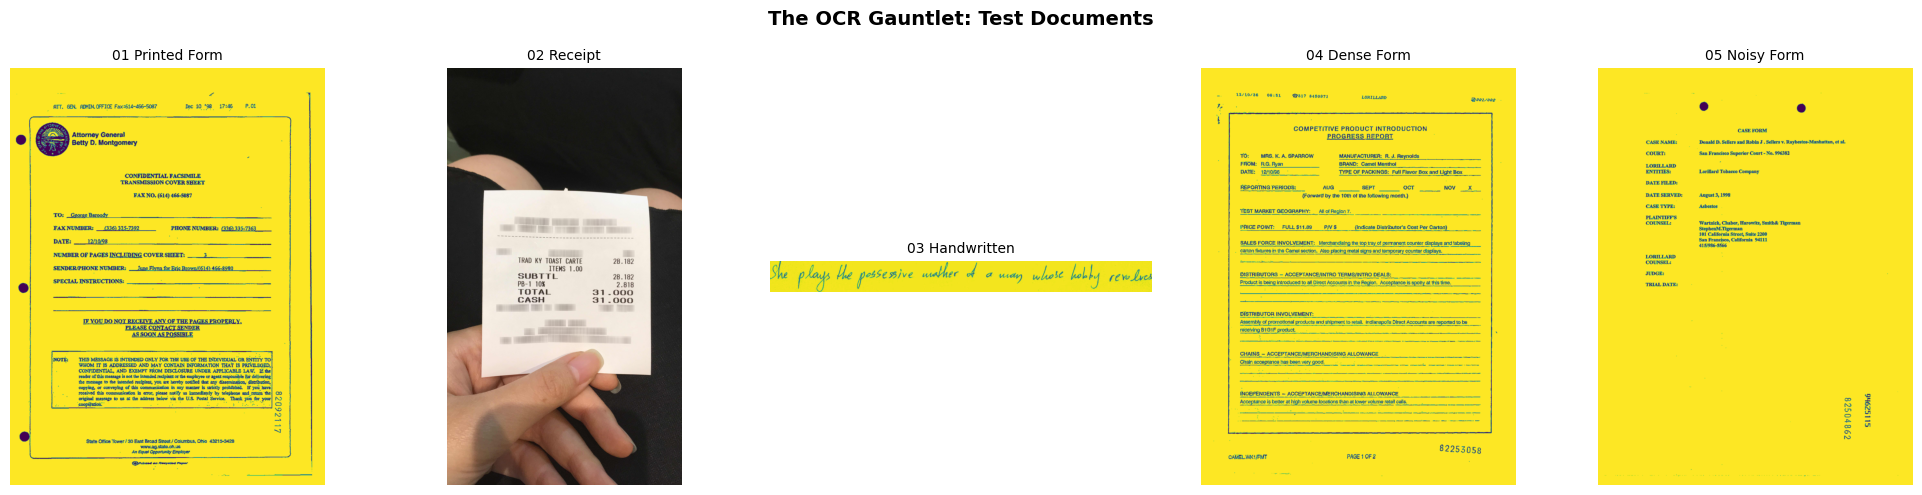

In [2]:
import matplotlib.pyplot as plt
from ocr_gauntlet.utils import SAMPLES_DIR

# list_samples() returns only samples WITH ground truth (for metrics)
# list_all_samples() includes visual-only samples too
samples = list_samples()
all_samples = list_all_samples()

print(f"Samples with ground truth (for metrics): {len(samples)}")
print(f"All samples (including visual-only):     {len(all_samples)}\n")

fig, axes = plt.subplots(1, len(all_samples), figsize=(4 * len(all_samples), 5))
if len(all_samples) == 1:
    axes = [axes]

for ax, name in zip(axes, all_samples):
    from PIL import Image as PILImage

    img = PILImage.open(SAMPLES_DIR / f"{name}.png")
    ax.imshow(img)
    label = name.replace("_", " ").title()
    if name not in samples:
        label += "\n(visual only)"
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.suptitle("The OCR Gauntlet: Test Documents", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from tqdm.notebook import tqdm
from ocr_gauntlet.engines import (
    run_tesseract,
    run_docling,
    run_dots_ocr,
    run_mistral_ocr,
    run_gemini,
)

TIERS = [
    ("Tesseract", run_tesseract, {}, "tesseract"),
    ("Docling + tesseract", run_docling, {"needs_path": True}, "docling"),
    ("dots.ocr (1.7B)", run_dots_ocr, {}, "dots_ocr"),
    ("Mistral OCR v3", run_mistral_ocr, {}, "mistral_ocr"),
    ("Gemini 3 Flash", run_gemini, {}, "gemini"),
]

results = []
raw_outputs = {}

for tier_name, runner, kwargs, requires in tqdm(TIERS, desc="Tiers"):
    if not engines.get(requires, False):
        print(f"⏭️  Skipping {tier_name}")
        continue

    for sample_name in tqdm(samples, desc=tier_name, leave=False):
        img, gt, img_path = load_sample(sample_name)
        try:
            if kwargs.get("needs_path"):
                text, meta = runner(image_path=img_path)
            else:
                text, meta = runner(img)

            pred_norm = normalize_text(text)
            gt_norm = normalize_text(gt)

            results.append(
                {
                    "engine": tier_name,
                    "document": sample_name,
                    "cer": cer(pred_norm, gt_norm),
                    "wer": wer(pred_norm, gt_norm),
                    "anls": anls(pred_norm, gt_norm),
                    "latency_ms": meta["latency_ms"],
                    "cost_per_1k_pages": meta.get("cost_per_1k_pages", 0),
                }
            )
            raw_outputs[(tier_name, sample_name)] = text
        except Exception as e:
            print(f"   ⚠️ {tier_name} x {sample_name}: {e}")

df = pd.DataFrame(results)
print(f"\n✅ {len(df)} results from {df['engine'].nunique()} engines")

Tiers:   0%|          | 0/5 [00:00<?, ?it/s]

Tesseract:   0%|          | 0/5 [00:00<?, ?it/s]

Docling + tesseract:   0%|          | 0/5 [00:00<?, ?it/s]

⏭️  Skipping dots.ocr (1.7B)


Mistral OCR v3:   0%|          | 0/5 [00:00<?, ?it/s]

Gemini 3 Flash:   0%|          | 0/5 [00:00<?, ?it/s]


✅ 20 results from 4 engines


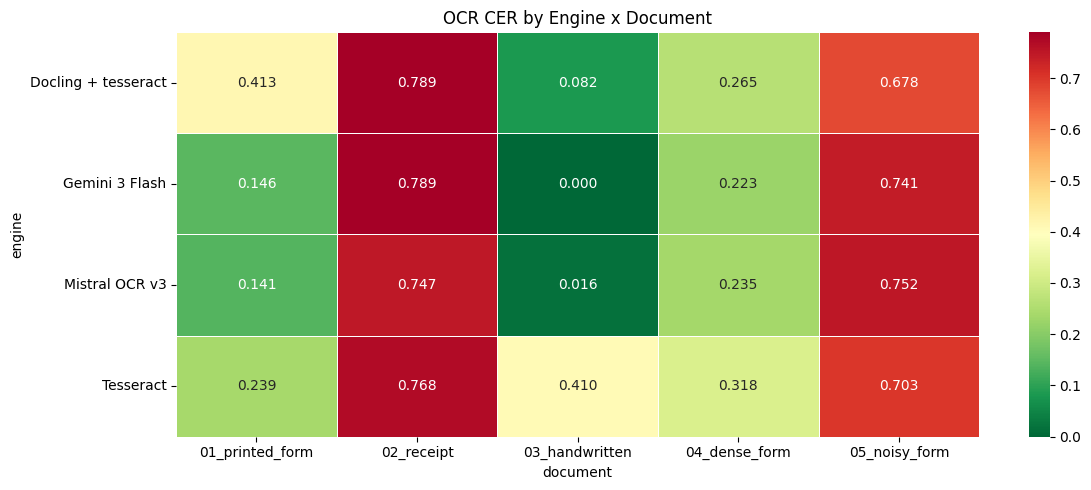

In [4]:
fig = results_heatmap(df)
plt.show()

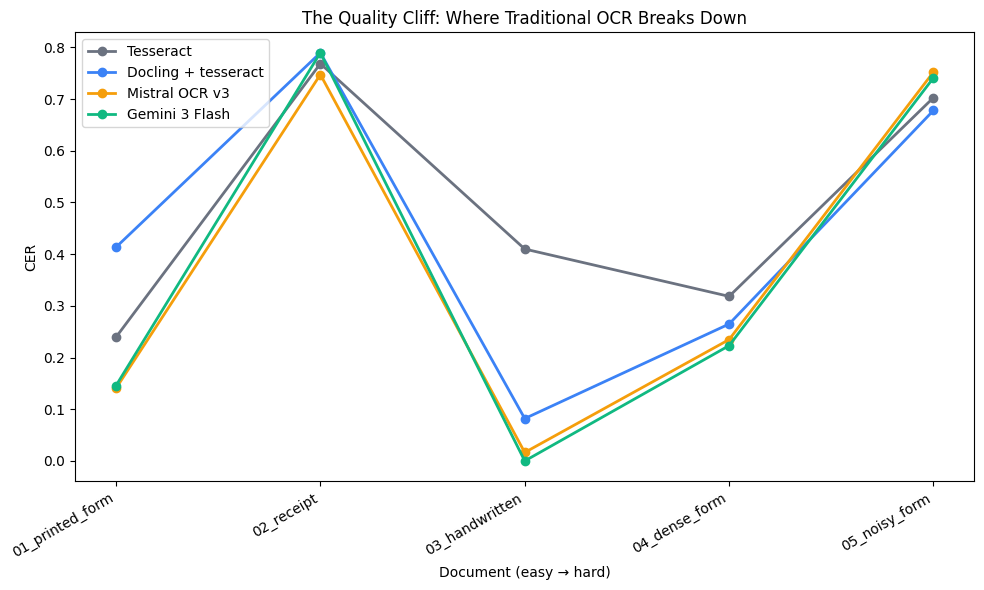

In [5]:
fig = quality_cliff_chart(df)
plt.show()

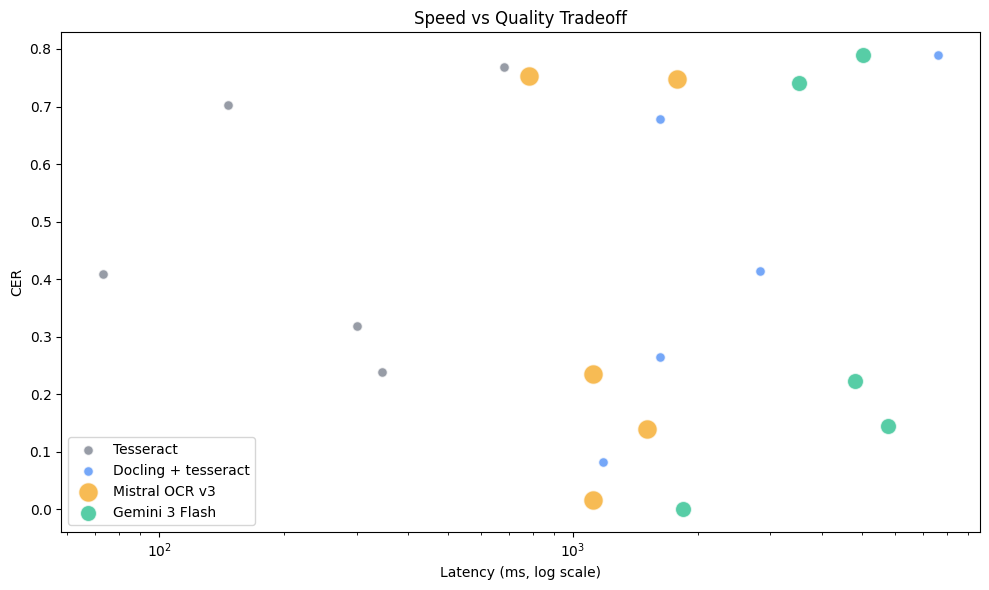

In [6]:
fig = speed_vs_quality(df)
plt.show()

In [7]:
hardest = df.groupby("document")["cer"].mean().idxmax()
print(f"Hardest document: {hardest}\n{'=' * 80}")
for tier_name, *_ in TIERS:
    key = (tier_name, hardest)
    if key in raw_outputs:
        print(f"\n--- {tier_name} ---")
        print(raw_outputs[key][:500])

Hardest document: 02_receipt

--- Tesseract ---
TRAD KY TOAST CARTE 28. 182

ITEMS 1.00
SUBTTL 28. 182
PB-1 10% 2.818
TOTAL 31.000
CASH 31.000

--- Docling + tesseract ---
TRAD KY TOAST CARTE ITEMS 1.00 SUBTTL PB-1 10% TOTAL CASH

28.182

28.182

2.818

31.000 31.000

--- Mistral OCR v3 ---
TRAD KY TOAST CARTE 28.182
ITEMS 1.00
SUBTTL 28.182
PB-1 10% 2.818
TOTAL 31.000
CASH 31.000

--- Gemini 3 Flash ---
TRAD KY TOAST CARTE
ITEMS 1.00                               28.182
SUBTTL                                   28.182
PB-1 10%                                  2.818
TOTAL                                    31.000
CASH                                     31.000


In [8]:
avg_cers = df.groupby("engine")["cer"].mean().to_dict()
for vol in [1_000, 10_000, 100_000, 1_000_000]:
    print(f"\n{'=' * 60}\n  📊 {vol:,} pages/month\n{'=' * 60}")
    display(cost_table(vol, avg_cers))


  📊 1,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.488,Free,CPU only
1,Docling + tesseract,0.446,Free,CPU only
2,dots.ocr (1.7B),N/A,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.378,$2,$2/1K pages
4,Gemini 3 Flash,0.380,$1,~$0.50/M input tokens



  📊 10,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.488,Free,CPU only
1,Docling + tesseract,0.446,Free,CPU only
2,dots.ocr (1.7B),N/A,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.378,$20,$2/1K pages
4,Gemini 3 Flash,0.380,$8,~$0.50/M input tokens



  📊 100,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.488,Free,CPU only
1,Docling + tesseract,0.446,Free,CPU only
2,dots.ocr (1.7B),N/A,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.378,$200,$2/1K pages
4,Gemini 3 Flash,0.380,$80,~$0.50/M input tokens



  📊 1,000,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.488,Free,CPU only
1,Docling + tesseract,0.446,Free,CPU only
2,dots.ocr (1.7B),N/A,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.378,"$2,000",$2/1K pages
4,Gemini 3 Flash,0.380,$800,~$0.50/M input tokens


In [9]:
best = df.loc[df.groupby("document")["cer"].idxmin()][["document", "engine", "cer"]]
print("🏆 Best engine per document type:")
display(best)
print("\n📖 Full guide: [blog link]")
print("🏟️ Live rankings: https://ocrarena.ai")

🏆 Best engine per document type:


,document,engine,cer
10,01_printed_form,Mistral OCR v3,0.140520
11,02_receipt,Mistral OCR v3,0.747368
17,03_handwritten,Gemini 3 Flash,0.000000
18,04_dense_form,Gemini 3 Flash,0.223058
9,05_noisy_form,Docling + tesseract,0.677928



📖 Full guide: [blog link]
🏟️ Live rankings: https://ocrarena.ai
